# Análisis Exploratorio de Datos (EDA)

*"EDA is detective work… The analyst of data needs both tools and understanding"*. **Tukey (1977)**

Es un proceso que conlleva un análisis sobre los datos, muchas veces constituye un primer acercamiento a los mismos, haciendo uso de técnicas de estadística descriptiva y visualización para entender su estructura, calidad y las relaciones entre variables, antes de plantear cualquier modelo.

# Bank Marketing como ejemplo

El dataset **Bank Marketing** contiene los registros de campañas de **telemarketing** (llamadas telefónicas) de una institución bancaria portuguesa, realizadas entre **mayo de 2008 y noviembre de 2010**, período que incluye el estallido de la crisis financiera internacional. El objetivo comercial de esas campañas era ofrecer telefónicamente un producto de **depósito a plazo fijo (term deposit)**.

El dataset es de acceso público y fue publicado originalmente en:

> S. Moro, P. Cortez and P. Rita. *A Data-Driven Approach to Predict the Success of Bank Telemarketing.* Decision Support Systems, Elsevier, 62:22-31, June 2014.

Fuente: [UCI Machine Learning Repository - Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)

### Teniendo un conjunto de datos bastante detallado de cada contacto comercial, ¿qué podemos conocer sobre el comportamiento de los prospectos? ¿Es posible anticipar quién va a suscribir el depósito antes de levantar el teléfono?

# Información del dataset

El archivo utilizado es **`bank-additional-full.csv`**, la versión completa (41.188 registros, 20 variables de entrada + 1 variable objetivo) del dataset Bank Marketing. Cada fila representa un **contacto telefónico** realizado a un cliente en el marco de una campaña; un mismo cliente puede aparecer más de una vez si fue contactado en distintas campañas.

## Diccionario de datos

Documentamos acá el significado *nominal* de cada campo, tal como figura en la fuente original. Como en cualquier dataset real, esto es un punto de partida: en la sección de preprocesamiento vamos a chequear si los valores que realmente aparecen se comportan como este diccionario sugiere.

<table>
<tr><td><strong>Variable</strong></td><td><strong>Descripción</strong></td><td><strong>Tipo</strong></td></tr>
<tr><td>age</td><td>Edad del cliente</td><td>numérica</td></tr>
<tr><td>job</td><td>Tipo de ocupación (admin., blue-collar, technician, management, retired, student, etc.)</td><td>categórica</td></tr>
<tr><td>marital</td><td>Estado civil (married, single, divorced — incluye viudos/as)</td><td>categórica</td></tr>
<tr><td>education</td><td>Nivel educativo alcanzado</td><td>categórica</td></tr>
<tr><td>default</td><td>¿Tiene crédito en default (mora)?</td><td>categórica (yes/no)</td></tr>
<tr><td>housing</td><td>¿Tiene préstamo hipotecario/vivienda?</td><td>categórica (yes/no)</td></tr>
<tr><td>loan</td><td>¿Tiene préstamo personal?</td><td>categórica (yes/no)</td></tr>
<tr><td>contact</td><td>Medio de contacto (cellular / telephone)</td><td>categórica</td></tr>
<tr><td>month</td><td>Mes del último contacto de esta campaña</td><td>categórica</td></tr>
<tr><td>day_of_week</td><td>Día de la semana del último contacto</td><td>categórica</td></tr>
<tr><td>duration</td><td>Duración en segundos del último contacto</td><td>numérica</td></tr>
<tr><td>campaign</td><td>Cantidad de contactos realizados durante esta campaña para este cliente (incluye el último)</td><td>numérica</td></tr>
<tr><td>pdays</td><td>Días desde el último contacto de una campaña previa</td><td>numérica</td></tr>
<tr><td>previous</td><td>Cantidad de contactos realizados antes de esta campaña para este cliente</td><td>numérica</td></tr>
<tr><td>poutcome</td><td>Resultado de la campaña de marketing anterior (success / failure / nonexistent)</td><td>categórica</td></tr>
<tr><td>emp.var.rate</td><td>Tasa de variación del empleo, indicador trimestral</td><td>numérica (contexto)</td></tr>
<tr><td>cons.price.idx</td><td>Índice de precios al consumidor, indicador mensual</td><td>numérica (contexto)</td></tr>
<tr><td>cons.conf.idx</td><td>Índice de confianza del consumidor, indicador mensual</td><td>numérica (contexto)</td></tr>
<tr><td>euribor3m</td><td>Tasa Euribor a 3 meses, indicador diario</td><td>numérica (contexto)</td></tr>
<tr><td>nr.employed</td><td>Cantidad de empleados, indicador trimestral</td><td>numérica (contexto)</td></tr>
<tr><td>y</td><td><strong>Variable objetivo</strong>: ¿el cliente suscribió el depósito a plazo?</td><td>categórica (yes/no)</td></tr>
</table>

Las últimas cinco variables son **indicadores socioeconómicos del contexto** (no son atributos propios del cliente), agregados por Moro et al. para capturar el efecto de la crisis financiera 2008-2010 sobre la propensión a ahorrar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Consistent figure size / style across the notebook
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.max_columns', 30)

In [2]:
# pandas can read a csv directly from inside a zip file
df = pd.read_csv('bank-additional-full.csv.zip', sep=';')
df.shape

(41188, 21)

# Descripción general de los datos

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# Check for fully duplicated rows
df.duplicated().sum()

12

Hay algunos registros duplicados. En este dataset son posibles (dos clientes con exactamente los mismos atributos e igual desenlace), pero de todas formas los descartamos para evitar sobre-representar ciertas combinaciones.

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(41176, 21)

# Del problema de negocio al problema analítico

Antes de tocar una sola línea de código de modelado conviene pararse a pensar el problema de negocio. Un dataset "listo para entrenar" ya viene con un montón de decisiones tomadas; vale la pena hacerlas explícitas.

## ¿Cuál es el problema real?

El banco quiere aumentar la suscripción de depósitos a plazo fijo mediante campañas de telemarketing. La tasa de conversión histórica del dataset es de apenas ~11%, y el call center tiene una **capacidad limitada** de llamadas por día/campaña. El problema de negocio no es "vender el depósito", sino **decidir a quién llamar (y en qué orden) con un recurso de contacto escaso**.

## ¿Todos los prospectos son igual de importantes?

No. Aunque el costo de contactarlos sea similar, difieren en:
- **probabilidad de conversión** (un cliente con historial positivo previo no es lo mismo que uno nunca contactado),
- **valor potencial** (monto que podría depositar, relación de largo plazo con el banco),
- **costo de "molestia"** (sobre-contactar a quien ya dijo que no genera desgaste de marca y eventualmente reclamos regulatorios).

## ¿Por qué no llamar a todos?

Porque cada llamada tiene un **costo operativo** (tiempo del agente, infraestructura del call center) y un **costo de oportunidad**: ese mismo minuto podría usarse para contactar a un prospecto con mayor probabilidad de conversión. Con una tasa base de conversión ~11%, llamar indiscriminadamente implica que ~9 de cada 10 llamadas no van a convertir. Además existen costos "blandos" (desgaste de la relación, opt-outs, límites regulatorios de contactabilidad) que no bajan por seguir llamando parejo a toda la base.

## ¿Cuál es el costo de cada acción?

El costo de *llamar* es razonablemente homogéneo por contacto (algunos minutos de un agente + costo de discado/sistema), independientemente de si el prospecto termina convirtiendo o no. Es decir, el costo variable no cambia mucho según a quién se llame — por eso el apalancamiento no está en abaratar la llamada, sino en **elegir mejor a quién llamar primero** dado un presupuesto de llamadas fijo.

## ¿Cuál es el mejor foco / cuál es el planteo analítico?

Conviene reformular la pregunta de negocio ("¿a quién ofrecerle el depósito?") como un **problema analítico de priorización (ranking/scoring)**, no de clasificación pura: dado un presupuesto de *N* llamadas, ¿cómo ordenar la base de prospectos por probabilidad (o valor esperado) de conversión para maximizar el resultado de la campaña con ese presupuesto? Esto es distinto de "clasificar bien a todos"; lo que importa es el orden relativo en el tramo superior de la lista.

## ¿Cuál sería el KPI?

Candidatos razonables, de más simple a más completo:
- **Tasa de conversión** de la campaña (baseline a superar).
- **Lift** sobre un llamado aleatorio, medido en el top-k% de la lista priorizada (gains/lift chart).
- **Costo por adquisición (CPA)** = costo total de llamadas / conversiones logradas.
- Idealmente, **valor esperado neto** = probabilidad de conversión × valor del depósito − costo de la llamada, si se contara con el valor monetario esperado por cliente (no disponible en este dataset).

## ¿Cómo se usaría la información de un modelo?

Un modelo de propensión a suscribir se usaría para **rankear** la base de prospectos antes de cada campaña y construir una lista de llamadas priorizada dentro del presupuesto disponible del call center, o para fijar un **umbral de score** a partir del cual conviene invertir el contacto. El modelo no reemplaza la llamada: la orienta. Este marco también obliga a pensar qué información está disponible *antes* de llamar (no después) — algo que vamos a poder chequear directamente en los datos más adelante.

# Preprocesamiento: valores nulos y outliers

## ¿Hay valores nulos?

In [7]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

No aparece ningún `NaN` explícito. Pero eso no garantiza que los datos estén completos: repasemos qué valores toma efectivamente cada variable categórica.

In [8]:
cat_cols = df.select_dtypes(include='object').columns.drop('y')

for c in cat_cols:
    print(c, '->', df[c].unique())

job -> ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital -> ['married' 'single' 'divorced' 'unknown']
education -> ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default -> ['no' 'unknown' 'yes']
housing -> ['no' 'yes' 'unknown']
loan -> ['no' 'yes' 'unknown']
contact -> ['telephone' 'cellular']
month -> ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week -> ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome -> ['nonexistent' 'failure' 'success']


Aparece la categoría **`unknown`** en varias variables — no estaba anticipada en el diccionario de datos de esta forma. Funciona como un **nulo encubierto**: el dato existe como categoría pero no aporta información real sobre el cliente. Cuantifiquemos cuánto pesa en cada variable antes de decidir qué hacer con ella.

In [9]:
unknown_pct = (df[cat_cols] == 'unknown').mean().sort_values(ascending=False) * 100
unknown_pct = unknown_pct[unknown_pct > 0]
unknown_pct

default      20.876239
education     4.201477
housing       2.404313
loan          2.404313
job           0.801438
marital       0.194288
dtype: float64

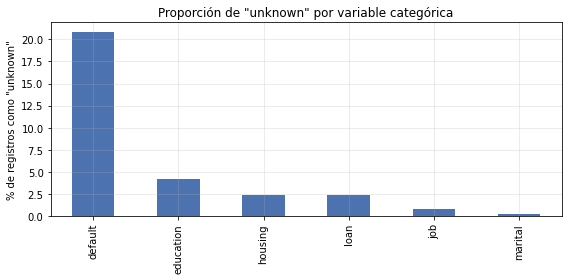

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
unknown_pct.plot.bar(ax=ax, color='#4C72B0')
ax.set_ylabel('% de registros como "unknown"')
ax.set_title('Proporción de "unknown" por variable categórica')
plt.tight_layout()
plt.show()

`default` tiene una proporción alta de `unknown` (~20%), lo cual es esperable: es información sensible que muchos clientes no confirman en una llamada comercial. El resto de las variables tiene proporciones bajas de `unknown`, manejables sin descartar registros.

## Valores extremos en variables numéricas

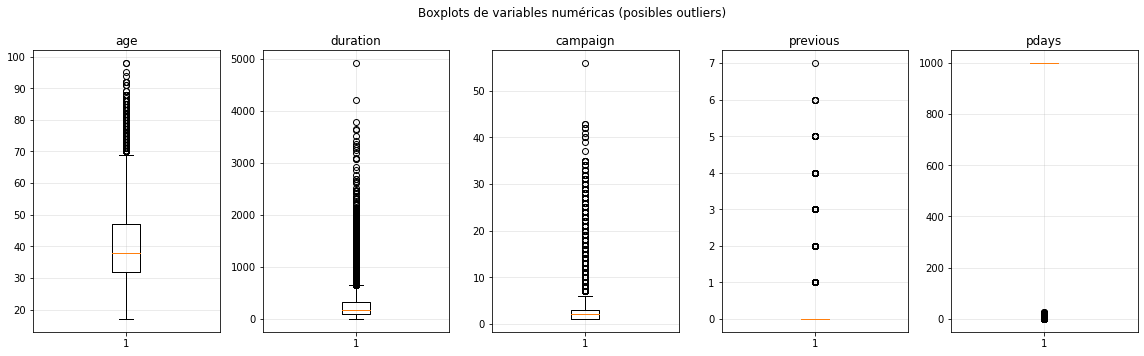

In [11]:
outlier_cols = ['age', 'duration', 'campaign', 'previous', 'pdays']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(16, 5))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col], vert=True)
    ax.set_title(col)
plt.suptitle('Boxplots de variables numéricas (posibles outliers)')
plt.tight_layout()
plt.show()

In [12]:
def iqr_outlier_summary(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return pd.Series({'lower_bound': lower, 'upper_bound': upper,
                       'n_outliers': n_out, 'pct_outliers': n_out / len(series) * 100})

pd.DataFrame({c: iqr_outlier_summary(df[c]) for c in outlier_cols}).T

,lower_bound,upper_bound,n_outliers,pct_outliers
age,9.5,69.5,468.0,1.136584
duration,-223.5,644.5,2963.0,7.195939
campaign,-2.0,6.0,2406.0,5.843210
previous,0.0,0.0,5625.0,13.660870
pdays,999.0,999.0,1515.0,3.679328


El resultado de `pdays` no se comporta como el de una variable numérica típica: el rango intercuartílico da **0** (el percentil 25 coincide con el percentil 75), y la regla de IQR marca como "outliers" cerca de 1.500 registros que, mirando la tabla, en realidad podrían ser los únicos casos con información real — no errores de carga. Vale la pena mirar esta variable más de cerca antes de seguir.

In [13]:
df['pdays'].describe()

count    41176.000000
mean       962.464810
std        186.937102
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

Percentil 25, mediana y percentil 75 coinciden exactamente en **999**. Es poco creíble que sea así para una medida real de "días desde el último contacto" — todo indica que 999 es un código, no una distancia. Confirmemos mirando la distribución de valores.

In [14]:
df['pdays'].value_counts().head(10)

999    39661
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
Name: pdays, dtype: int64

Confirmado: **`pdays = 999` es un valor centinela**, usado para codificar "nunca fue contactado en una campaña previa" (~96% de los registros), y conviven con él un puñado de valores que sí son días reales para el resto de los casos. Tratar `pdays` tal cual viene, como si fuera puramente numérica, sesgaría cualquier estadística que se calcule sobre ella (media, desvío, correlaciones). La forma correcta de usarla es separarla en una variable indicadora (¿fue contactado antes?) más el valor real de días cuando corresponde — la construimos en la sección de nuevas variables.

Para el resto de las variables numéricas (`age`, `duration`, `campaign`, `previous`), los "outliers" detectados por la regla de IQR (edades altas, llamadas muy largas, muchos contactos en la campaña) sí son en su mayoría **valores reales, no errores de carga**: clientes jubilados de edad avanzada, llamadas efectivamente largas, campañas insistentes sobre un mismo cliente. No corresponde eliminarlos; sí conviene tenerlos presentes porque pueden traccionar de más ciertas métricas (medias, correlaciones) y, según el algoritmo que se use más adelante, podría convenir acotarlos (*capping*) o transformarlos (log).

# Estadística descriptiva por variable

## Variables numéricas: medidas de centralidad y dispersión

In [15]:
all_numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                     'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

desc = df[all_numeric_cols].describe().T
desc['iqr'] = desc['75%'] - desc['25%']
desc['cv'] = desc['std'] / desc['mean']  # coefficient of variation
desc

,count,mean,std,min,25%,50%,75%,max,iqr,cv
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000,15.000,0.260362
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000,217.000,1.003831
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000,2.000,1.078835
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000,0.000,0.194227
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000,0.000,2.860844
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400,3.200,19.175460
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767,0.919,0.006186
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900,6.300,-0.114260
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045,3.617,0.478955
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100,129.000,0.013983


`pdays` y `previous` tienen la media muy influenciada por el valor centinela 999 y por la mayoría de ceros respectivamente — se leen mejor a través de la variable indicadora que construimos más adelante. Los indicadores de contexto (`emp.var.rate`, `euribor3m`, `nr.employed`) tienen rangos muy acotados: son series casi discretas (pocos valores distintos, uno por trimestre/mes).

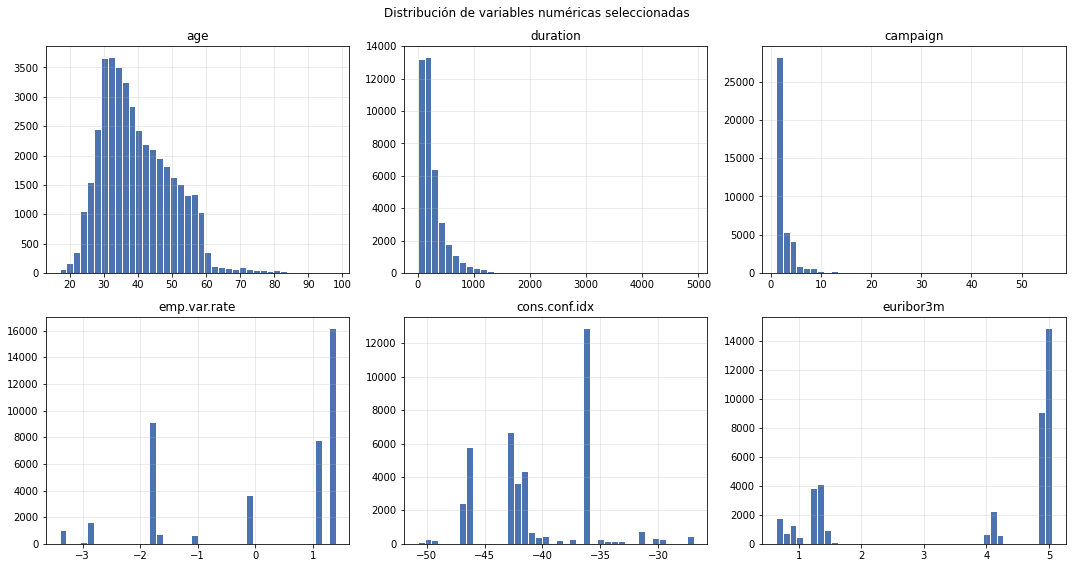

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
hist_cols = ['age', 'duration', 'campaign', 'emp.var.rate', 'cons.conf.idx', 'euribor3m']
for ax, col in zip(axes.flat, hist_cols):
    ax.hist(df[col], bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(col)
plt.suptitle('Distribución de variables numéricas seleccionadas')
plt.tight_layout()
plt.show()

## Variables categóricas: frecuencias

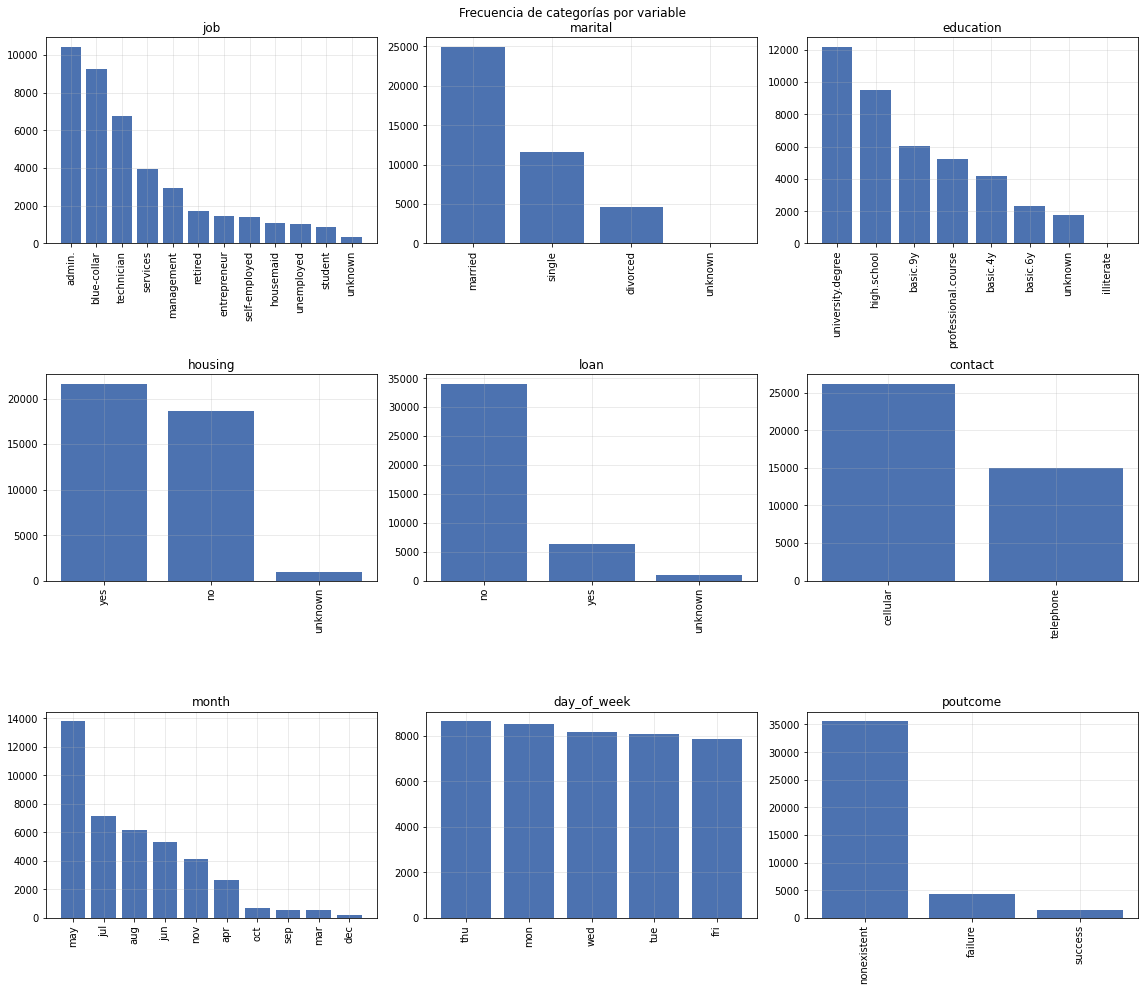

In [17]:
cat_plot_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact',
                  'month', 'day_of_week', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for ax, col in zip(axes.flat, cat_plot_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color='#4C72B0')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=90)
plt.suptitle('Frecuencia de categorías por variable')
plt.tight_layout()
plt.show()

La base está dominada por perfiles `admin.` y `blue-collar`, clientes `married`, contacto mayormente `cellular`, y una fuerte concentración de campaña en `may`. `poutcome` muestra que a la gran mayoría (`nonexistent`) nunca se la había contactado en una campaña anterior — consistente con lo que ya habíamos visto en `pdays`.

# Análisis y correlación con el target

In [18]:
df['y_bin'] = (df['y'] == 'yes').astype(int)
baseline_rate = df['y_bin'].mean()
print(f'Tasa de conversión base: {baseline_rate:.2%}')

Tasa de conversión base: 11.27%


## Correlación entre variables numéricas

/var/folders/8m/_b5wkl_14pb60ymzr5xbdgr40000gn/T/ipykernel_58291/3784375214.py:12: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  fig.colorbar(im, ax=ax, label='correlación de Pearson')


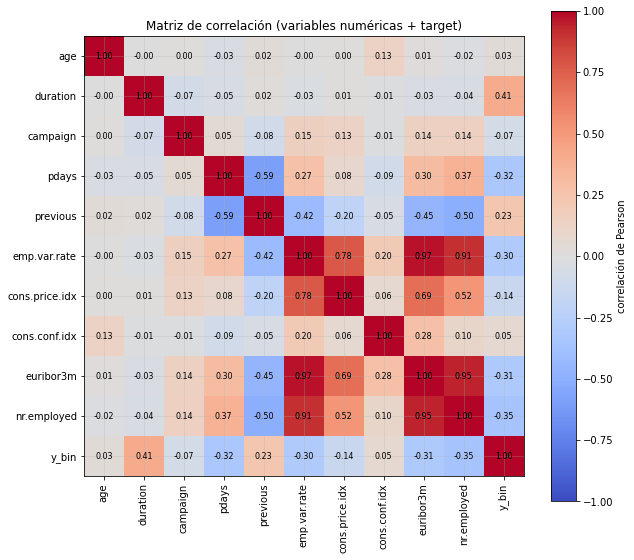

In [19]:
corr = df[all_numeric_cols + ['y_bin']].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='correlación de Pearson')
ax.set_title('Matriz de correlación (variables numéricas + target)')
plt.tight_layout()
plt.show()

Los cinco indicadores de contexto económico están **fuertemente correlacionados entre sí** (es la misma crisis reflejada en distintos indicadores), lo cual es esperable e implica redundancia. `duration` es la variable con mayor correlación positiva con el target — pero la duración de la llamada solo se conoce **después** de haber llamado, así que no sirve como predictor operativo pre-llamada: es información de "después del hecho", un caso claro de *data leakage* que ya habíamos anticipado al plantear el problema analítico.

## Variables numéricas vs. target

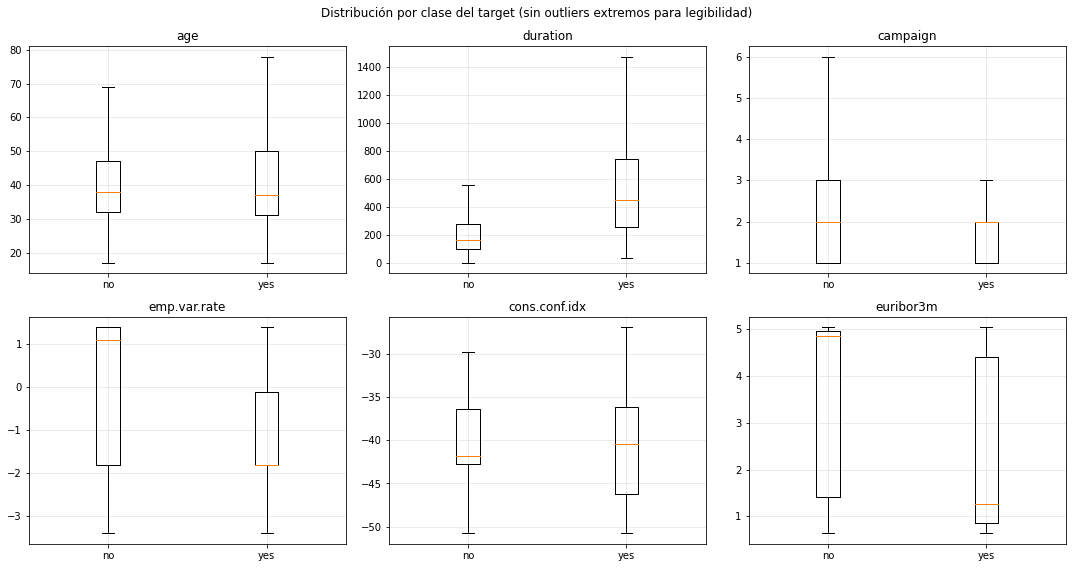

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
box_cols = ['age', 'duration', 'campaign', 'emp.var.rate', 'cons.conf.idx', 'euribor3m']
for ax, col in zip(axes.flat, box_cols):
    data_no = df.loc[df['y'] == 'no', col]
    data_yes = df.loc[df['y'] == 'yes', col]
    ax.boxplot([data_no, data_yes], labels=['no', 'yes'], showfliers=False)
    ax.set_title(col)
plt.suptitle('Distribución por clase del target (sin outliers extremos para legibilidad)')
plt.tight_layout()
plt.show()

Quienes suscriben el depósito tienden a haber tenido llamadas más largas (leakage ya comentado), campañas con **menos** contactos insistentes, y contactos en momentos con indicadores económicos más favorables (`emp.var.rate` y `euribor3m` más bajos) — coherente con el contexto de crisis 2008-2010.

## Variables categóricas vs. target: tasa de conversión por categoría

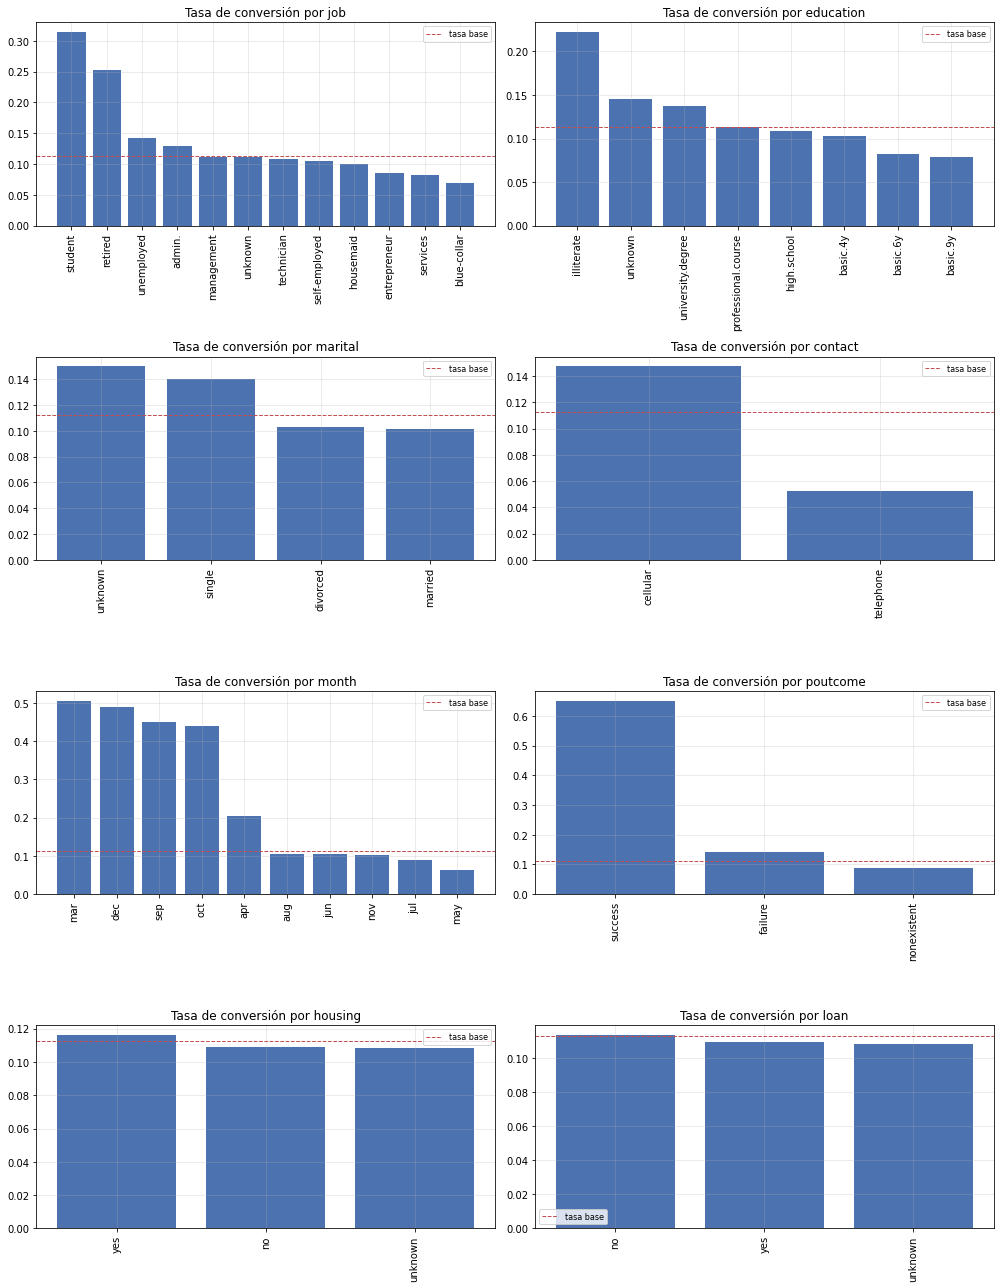

In [21]:
cat_conv_cols = ['job', 'education', 'marital', 'contact', 'month', 'poutcome', 'housing', 'loan']

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, col in zip(axes.flat, cat_conv_cols):
    rate = df.groupby(col)['y_bin'].mean().sort_values(ascending=False)
    ax.bar(rate.index, rate.values, color='#4C72B0')
    ax.axhline(baseline_rate, color='#C44E52', linestyle='--', linewidth=1, label='tasa base')
    ax.set_title(f'Tasa de conversión por {col}')
    ax.tick_params(axis='x', rotation=90)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

`poutcome = success` (haber convertido en una campaña anterior) es, por lejos, la señal categórica más fuerte — lo cual encaja con lo que ya sospechábamos al descubrir el valor centinela de `pdays`. `student` y `retired` convierten muy por encima del promedio dentro de `job`. El mes de contacto también importa mucho (`mar`, `dec`, `sep`, `oct` — meses de bajo volumen de campaña — muestran tasas de conversión bastante más altas que `may`, el mes de mayor volumen).

# Nuevas variables a partir de las existentes

A partir del análisis anterior, algunas variables derivadas que podrían aportar señal:

In [22]:
# Flag: was this client contacted in a previous campaign? (decodes the pdays=999 sentinel found above)
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

# Total historical contact effort across campaigns (current + previous)
df['total_contacts'] = df['campaign'] + df['previous']

# Broad age segments, easier to read than raw age for business rules
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100],
                          labels=['<=30', '31-45', '46-60', '60+'])

# Ordinal encoding of previous outcome: no history < failure < success
poutcome_score_map = {'nonexistent': 0, 'failure': 1, 'success': 2}
df['poutcome_score'] = df['poutcome'].map(poutcome_score_map)

# Quarter derived from month, to align with the quarterly economic indicators
month_to_quarter = {'jan': 1, 'feb': 1, 'mar': 1, 'apr': 2, 'may': 2, 'jun': 2,
                     'jul': 3, 'aug': 3, 'sep': 3, 'oct': 4, 'nov': 4, 'dec': 4}
df['quarter'] = df['month'].map(month_to_quarter)

df[['was_contacted_before', 'total_contacts', 'age_group', 'poutcome_score', 'quarter']].head()

,was_contacted_before,total_contacts,age_group,poutcome_score,quarter
0,0,1,46-60,0,2
1,0,1,46-60,0,2
2,0,1,31-45,0,2
3,0,1,31-45,0,2
4,0,1,46-60,0,2


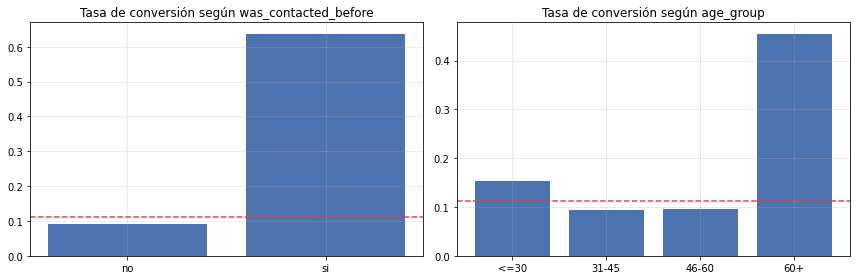

In [23]:
# Quick sanity check: do the new variables actually carry signal?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rate_contacted = df.groupby('was_contacted_before')['y_bin'].mean()
axes[0].bar(['no', 'si'], rate_contacted.values, color='#4C72B0')
axes[0].axhline(baseline_rate, color='#C44E52', linestyle='--')
axes[0].set_title('Tasa de conversión según was_contacted_before')

rate_age = df.groupby('age_group', observed=True)['y_bin'].mean()
axes[1].bar(rate_age.index.astype(str), rate_age.values, color='#4C72B0')
axes[1].axhline(baseline_rate, color='#C44E52', linestyle='--')
axes[1].set_title('Tasa de conversión según age_group')
plt.tight_layout()
plt.show()

`was_contacted_before` confirma ser una señal muy fuerte (coherente con `poutcome`). `age_group` muestra un patrón en forma de "U": los extremos etarios (jóvenes y clientes de 60+, típicamente estudiantes y jubilados) convierten más que el segmento adulto-medio — consistente con lo visto en `job`.

# Baselines: reglas simples sin Machine Learning

Antes de entrenar cualquier modelo conviene preguntarse qué tan lejos se puede llegar con reglas de negocio simples, directamente derivadas del EDA. Esto define el **piso** que un modelo debería superar para justificar su complejidad.

In [24]:
def rule_gains(df, mask, name):
    segment = df[mask]
    n = len(segment)
    rate = segment['y_bin'].mean() if n else 0
    return {
        'regla': name,
        'n_prospectos': n,
        '%_de_la_base': n / len(df) * 100,
        'tasa_conversion': rate,
        'lift_vs_base': rate / baseline_rate if baseline_rate else 0,
        '%_positivos_capturados': segment['y_bin'].sum() / df['y_bin'].sum() * 100,
    }

rules = {
    'poutcome == success': df['poutcome'] == 'success',
    'was_contacted_before': df['was_contacted_before'] == 1,
    'previous > 0': df['previous'] > 0,
    'job in (student, retired)': df['job'].isin(['student', 'retired']),
    'contact == cellular': df['contact'] == 'cellular',
}

gains_table = pd.DataFrame([rule_gains(df, mask, name) for name, mask in rules.items()])
gains_table = gains_table.sort_values('lift_vs_base', ascending=False).reset_index(drop=True)
gains_table

,regla,n_prospectos,%_de_la_base,tasa_conversion,lift_vs_base,%_positivos_capturados
0,poutcome == success,1373,3.334467,0.651129,5.779453,19.271395
1,was_contacted_before,1515,3.679328,0.638284,5.665440,20.845010
2,"job in (student, retired)",2593,6.297358,0.273428,2.426965,15.283466
3,previous > 0,5625,13.660870,0.266489,2.365369,32.312998
4,contact == cellular,26135,63.471440,0.147389,1.308228,83.035137


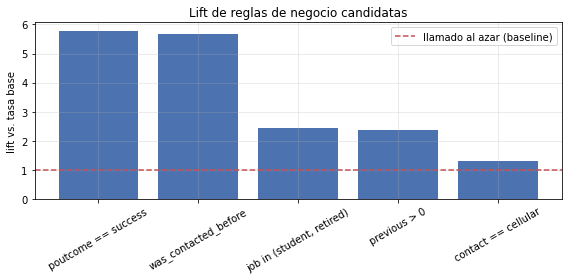

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(gains_table['regla'], gains_table['lift_vs_base'], color='#4C72B0')
ax.axhline(1, color='#C44E52', linestyle='--', label='llamado al azar (baseline)')
ax.set_ylabel('lift vs. tasa base')
ax.set_title('Lift de reglas de negocio candidatas')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.show()

Las reglas basadas en historial previo (`poutcome == success`, `was_contacted_before`, `previous > 0`) tienen un lift muy alto (>2x-5x) pero cubren una porción chica de la base: la mayoría de los prospectos nunca fue contactada antes, así que solas no alcanzan para armar una lista de llamadas grande. Conviene combinarlas con una regla de mayor cobertura.

In [26]:
# Combined priority rule: anyone with a positive contact history, OR a
# historically high-converting job segment, called first
priority_mask = (
    (df['poutcome'] == 'success') |
    (df['was_contacted_before'] == 1) |
    (df['job'].isin(['student', 'retired']))
)

combined = rule_gains(df, priority_mask, 'regla combinada (historial positivo OR student/retired)')
pd.Series(combined)

regla                     regla combinada (historial positivo OR student...
n_prospectos                                                           3793
%_de_la_base                                                       9.211677
tasa_conversion                                                    0.383865
lift_vs_base                                                       3.407205
%_positivos_capturados                                            31.386075
dtype: object

La regla combinada llama a una fracción minoritaria de la base y, aun así, concentra una porción desproporcionada de las conversiones totales — un lift claramente por encima de 1 con una cobertura razonable. Es una heurística simple, **sin ningún modelo**, que ya mejora sustancialmente sobre llamar a la base completa en orden aleatorio, y no usa `duration` (evita el leakage). Este es el **baseline a superar** por cualquier modelo predictivo posterior.

# Conclusiones

- El dataset está fuertemente desbalanceado: solo ~11% de los contactos terminan en conversión.
- No hay nulos explícitos, pero el propio recorrido por los valores únicos reveló que varias variables categóricas usan `unknown` como nulo encubierto (`default` en particular, 20% aprox), y que `pdays` esconde un valor centinela `999` (96% aprox de los casos) para "nunca contactado" — ninguno de los dos problemas era evidente de antemano; surgieron de mirar los datos, no de la documentación.
- `duration` es la variable más correlacionada con el target, pero **no está disponible antes de llamar**: incluirla en un modelo predictivo operativo sería *data leakage*.
- El historial de contacto previo (`poutcome`, `was_contacted_before`, `previous`) es, por lejos, la señal más fuerte y disponible *ex-ante*. El contexto económico (`emp.var.rate`, `euribor3m`) y el perfil ocupacional (`student`, `retired`) también aportan señal relevante.
- Reformulando el problema de negocio como un problema de **priorización de contactos bajo presupuesto limitado** (en vez de clasificación binaria "pura"), unas pocas reglas simples ya logran un lift considerable sobre el llamado aleatorio, capturando una fracción importante de las conversiones con una fracción menor de la base.
- Ese resultado define el **baseline** contra el cual cualquier modelo de Machine Learning posterior debe medirse: no alcanza con "predecir bien", tiene que superar en lift/costo por adquisición a estas reglas simples derivadas del EDA.